<a href="https://colab.research.google.com/github/mqquiroz/Fluid_Mechanics/blob/main/Campo_Velocidades.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###***Líneas de corriente en el plano xy***

$$\vec{V}=(u,v)=(0.5+0.8x)\hat{i}+(1.5-0.8y)\hat{j}$$


Para el campo bidimensional estacionario e incompresible de velocidad, trace la gráfica de varias líneas de corriente en la mitad derecha del flujo ($x > 0$). Grafique también el campo de velocidad.

In [1]:
#Librerias
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

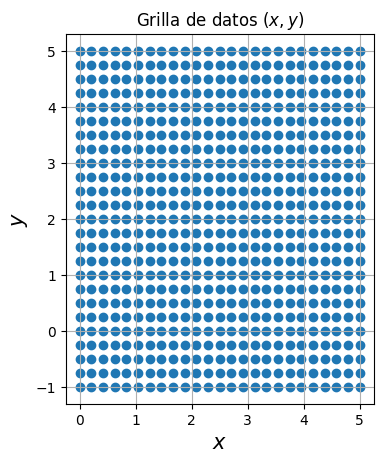

In [3]:
#Creacion de Grilla
xmin = 0
xmax = 5
nx   = 25
ymin = -1
ymax = 5
ny   = 25

x = np.linspace(xmin,xmax,nx)
y = np.linspace(ymin,ymax,ny)
X,Y = np.meshgrid(x,y)

plt.plot()
plt.scatter(X,Y)
plt.title('Grilla de datos $(x,y)$')
plt.xlabel('$x$',fontsize=15)
plt.ylabel('$y$',fontsize=15)
plt.axis('scaled')
plt.grid()
plt.show()

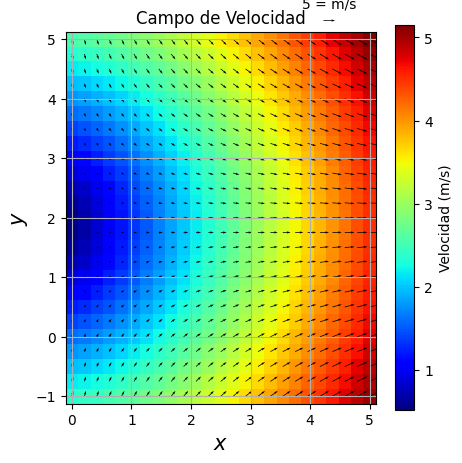

In [5]:
#Campo de velocidad
u = 0.5 + 0.8*X
v = 1.5 - 0.8*Y

#Magnitud del vector velocidad
V = np.sqrt(u**2 + v**2)

#Graficar en la mitad derecha del flujo x>0

plt.figure(figsize=(5,5))

plt.pcolormesh(X,Y,V,cmap='jet')
cbar = plt.colorbar()
cbar.set_label('Velocidad (m/s)')

flechas = plt.quiver(X,Y,u,v,pivot='tail') #'tail','middle','tip'
plt.quiverkey(flechas,0.85,1.03,5,'5 = m/s')#, labelpos="E")

#plt.streamplot(X,Y,u,v,density=0.6,color='k',linewidth=0.5)




plt.title('Campo de Velocidad')
plt.xlabel('$x$',fontsize=15)
plt.ylabel('$y$',fontsize=15)
plt.axis('scaled')
plt.grid()
plt.show()

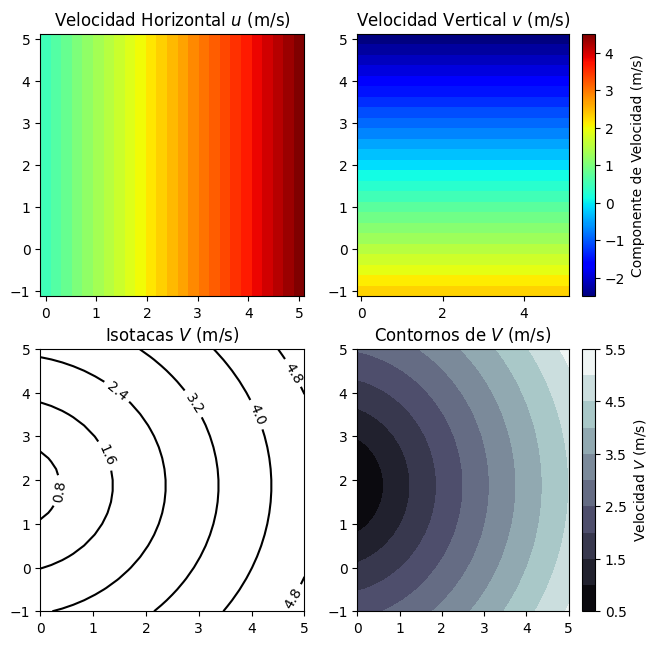

In [69]:
fig, axs = plt.subplots(2, 2,figsize=(7.5,7.5))

axs[0, 0].pcolormesh(X,Y,u,cmap='jet',vmin=np.min(v),vmax=np.max(u))
axs[0, 0].set_title('Velocidad Horizontal $u$ (m/s)')

PC =axs[0, 1].pcolormesh(X,Y,v,cmap='jet',vmin=np.min(v),vmax=np.max(u))
axs[0, 1].set_title('Velocidad Vertical $v$ (m/s)')

C = axs[1, 0].contour(X,Y,V, levels=5, colors='k', linestyles='-')
C.clabel()
axs[1, 0].set_title('Isotacas $V$ (m/s)')

CS = axs[1, 1].contourf(X, Y, V, 10, cmap='bone')
axs[1, 1].set_title('Contornos de $V$ (m/s)')

#paletas de colores
cbar1 = fig.colorbar(PC)
cbar2 = fig.colorbar(CS)
cbar1.ax.set_ylabel('Componente de Velocidad (m/s)')
cbar2.ax.set_ylabel('Velocidad $V$ (m/s)')

plt.show()

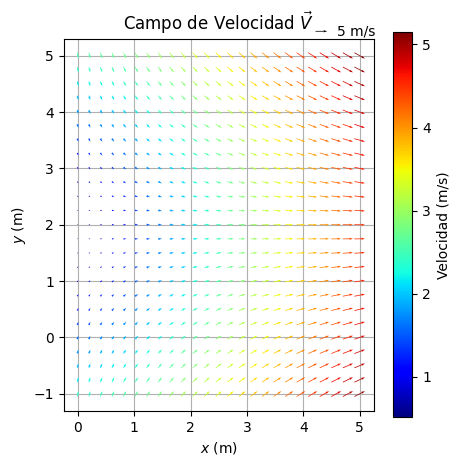

In [87]:
plt.figure(figsize=(5,5))


Q = plt.quiver(X,Y,u,v,V,pivot="middle", cmap='jet',zorder=100)
plt.quiverkey(Q, 0.85, 1.02, 5, "5 m/s", labelpos="E")
cbar = plt.colorbar()
cbar.set_label('Velocidad (m/s)')
plt.axis("scaled")
plt.title('Campo de Velocidad $\\vec{V}$')
plt.xlabel('$x$ (m)')
plt.ylabel('$y$ (m)')
plt.grid(zorder=-100)

plt.savefig('Campo_Velocidad.png',bbox_inches='tight',dpi=300)

plt.show()

Líneas de Corriente (Solución Analítica)

*   El flujo es estacionario e incompresible.
*   El flujo es bidimensional, no tridimensional, entonces no hay componente en $z$ de la velocidad y no se tiene variación de $u(z)$ o $v(z)$.

Las líneas de corriente en el plano $xy$ se determinan como:

$$\left(\frac{dy}{dx} \right)_{a \ lo \ largo \ de \ una \ línea \ de \ corriente}=\frac{v}{u}$$

Con el campo de velocidad:

$$\vec{V}=(u,v)=(0.5+0.8x)\hat{i}+(1.5-0.8y)\hat{j}$$

Sustituyendo $u$ y $v$:

$$\left(\frac{dy}{dx} \right)=\frac{1.5-0.8y}{0.5+0.8x}$$

Resolviendo la EDO por separación de variables:

$$\frac{dy}{1.5-0.8y}=\frac{dx}{0.5+0.8x}$$

$$\int\frac{dy}{1.5-0.8y}=\int\frac{dx}{0.5+0.8x}$$

Resolviendo las integrales por sustitución, tomando:

$$u=1.5-0.8y  \  ;  \  du=-0.8dy  \  ;  \  w=0.5+0.8x  \  ;  \  dw=0.8dx$$

Reemplazando:

$$\frac{1}{-0.8}\int\frac{du}{u}=\frac{1}{0.8}\int\frac{dw}{w}$$

$$-\ln(1.5-0.8y) + C_1 = \ln(0.5+0.8x) + C_2$$

$$\ln(1.5-0.8y)+\ln(0.5+0.8x)=-(C_1+C_2)$$

$$\ln\left[(1.5-0.8y)\cdot(0.5+0.8x)\right] = -(C_1+C_2) \qquad /\cdot e^{()}$$

$$(1.5-0.8y)\cdot(0.5+0.8x) = e^{-(C_1+C_2)}$$

$$(1.5-0.8y)\cdot(0.5+0.8x) = C_3$$

$$1.5-0.8y = \frac{C_3}{0.5+0.8x}$$

$$y=\frac{1}{-0.8}\left(\frac{C_3}{0.5+0.8x}-1.5 \right)$$

Por lo tanto, La expresión que define las líneas de corriente es:

$$y(x)=\frac{C}{0.5+0.8x}+1.875$$

Donde $C$ es una constante de integración, que puede tomar cualquier valor.

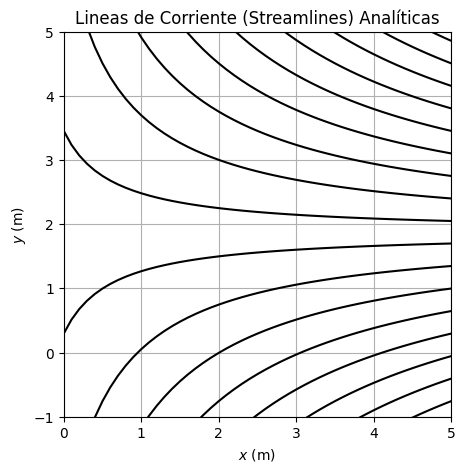

In [119]:
#Grafica de líneas de corrientes de forma manual

plt.figure(figsize=(5,5))

C = np.linspace(-15, 15, 20)
xx = np.arange(0,5+0.1,0.1)

#y_lc = ((C)/(0.5+(0.8*X)))+1.875


for i in range(len(C)):
  yy = ((C[i])/(0.5+(0.8*xx)))+1.875
  plt.plot(x,yy,'k')

plt.xlim([0,5])
plt.ylim([-1,5])
plt.xlabel('$x$ (m)')
plt.ylabel('$y$ (m)')
plt.grid()
plt.title('Lineas de Corriente (Streamlines) Analíticas')
plt.show()

In [95]:
yy

NameError: name 'yy' is not defined